In [ ]:
!pip install datasets pesq pystoi

In [ ]:
!pip install datasets

import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio

from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.rnn as rnn_utils

In [ ]:
ds = load_dataset("JacobLinCool/VoiceBank-DEMAND-16k")

In [ ]:
class HFVoiceBankDataset(Dataset):
    def __init__(self, hf_dataset):
        self.dataset = hf_dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        clean = torch.tensor(sample['clean']['array'], dtype=torch.float32)
        noisy = torch.tensor(sample['noisy']['array'], dtype=torch.float32)

        return noisy, clean

In [ ]:
def collate_fn(batch):
    noisy, clean = zip(*batch)

    noisy = rnn_utils.pad_sequence(noisy, batch_first=True)
    clean = rnn_utils.pad_sequence(clean, batch_first=True)

    return noisy, clean

In [ ]:
train_dataset = HFVoiceBankDataset(ds["train"])

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

In [ ]:
def stft(x):
    window = torch.hann_window(512).to(x.device)
    return torch.stft(
        x,
        n_fft=512,
        hop_length=128,
        win_length=512,
        window=window,
        return_complex=True
    )

def istft(x):
    window = torch.hann_window(512).to(x.device)
    return torch.istft(
        x,
        n_fft=512,
        hop_length=128,
        win_length=512,
        window=window
    )

In [ ]:
class DCCRN(nn.Module):
    def __init__(self):
        super(DCCRN, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(2, 16, (5,2), stride=(2,1), padding=(2,1)),
            nn.BatchNorm2d(16),
            nn.PReLU(),

            nn.Conv2d(16, 32, (5,2), stride=(2,1), padding=(2,1)),
            nn.BatchNorm2d(32),
            nn.PReLU(),

            nn.Conv2d(32, 64, (5,2), stride=(2,1), padding=(2,1)),
            nn.BatchNorm2d(64),
            nn.PReLU()
        )

        self.lstm = None
        self.fc = None

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, (5,2), stride=(2,1), padding=(2,1), output_padding=(1,0)),
            nn.BatchNorm2d(32),
            nn.PReLU(),

            nn.ConvTranspose2d(32, 16, (5,2), stride=(2,1), padding=(2,1), output_padding=(1,0)),
            nn.BatchNorm2d(16),
            nn.PReLU(),

            nn.ConvTranspose2d(16, 2, (5,2), stride=(2,1), padding=(2,1), output_padding=(1,0))
        )

    def forward(self, x):
        spec = stft(x)

        real = spec.real
        imag = spec.imag

        x = torch.stack([real, imag], dim=1)

        enc = self.encoder(x)

        B, C, F, T = enc.shape

        enc = enc.permute(0,3,1,2).contiguous().view(B, T, -1)

        # Dynamic LSTM
        if self.lstm is None:
            input_size = enc.shape[-1]

            self.lstm = nn.LSTM(input_size, 256, num_layers=2, batch_first=True).to(enc.device)
            self.fc = nn.Linear(256, input_size).to(enc.device)

        out, _ = self.lstm(enc)

        # Map back to original size
        out = self.fc(out)

        # Reshape back
        out = out.view(B, T, C, F).permute(0,2,3,1)

        dec = self.decoder(out)

        # 🔥 CRITICAL FIX (ISTFT SHAPE)
        orig_F = spec.shape[1]
        orig_T = spec.shape[2]

        real = dec[:, 0][:, :orig_F, :orig_T]
        imag = dec[:, 1][:, :orig_F, :orig_T]

        enhanced = torch.complex(real, imag)

        waveform = istft(enhanced)

        return waveform

In [ ]:
def si_snr_loss(est, target):
    eps = 1e-8

    target = target - target.mean(dim=-1, keepdim=True)
    est = est - est.mean(dim=-1, keepdim=True)

    s_target = torch.sum(est * target, dim=-1, keepdim=True) * target / (torch.sum(target**2, dim=-1, keepdim=True) + eps)
    e_noise = est - s_target

    loss = -10 * torch.log10(torch.sum(s_target**2, dim=-1) / (torch.sum(e_noise**2, dim=-1) + eps))

    return loss.mean()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DCCRN().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for noisy, clean in train_loader:
        noisy = noisy.to(device)
        clean = clean.to(device)

        optimizer.zero_grad()

        output = model(noisy)

        min_len = min(output.shape[1], clean.shape[1])
        loss = si_snr_loss(output[:, :min_len], clean[:, :min_len])

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: -8.013769930007753
Epoch 2, Loss: -8.344748032367841
Epoch 3, Loss: -8.571030559092296
Epoch 4, Loss: -8.743432018354746
Epoch 5, Loss: -8.865957583048704
Epoch 6, Loss: -8.944468352034871
Epoch 7, Loss: -9.01875847532722
Epoch 8, Loss: -9.0782959131589
Epoch 9, Loss: -9.139855253667598
Epoch 10, Loss: -9.17689935205523


In [ ]:
model.eval()

noisy, clean = train_dataset[0]
noisy = noisy.unsqueeze(0).to(device)

with torch.no_grad():
    enhanced = model(noisy).cpu().squeeze()

torchaudio.save("enhanced.wav", enhanced.unsqueeze(0), 16000)
torchaudio.save("noisy.wav", noisy.cpu(), 16000)

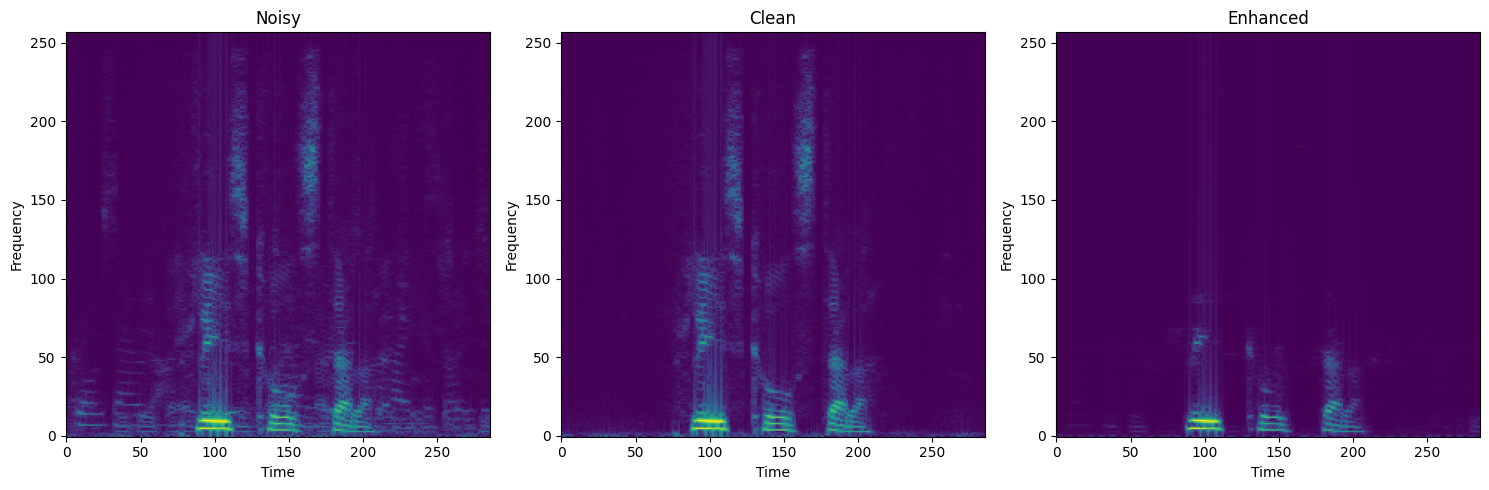

In [ ]:
import matplotlib.pyplot as plt
import torch

# ----------- Step 1: Get sample output from model -----------
model.eval()

noisy, clean = train_dataset[0]

noisy_input = noisy.unsqueeze(0).to(device)

with torch.no_grad():
    enhanced = model(noisy_input).cpu().squeeze()

# ----------- Step 2: Spectrogram function (FIXED) -----------
def plot_spec(wave, title):
    # Ensure 1D waveform
    if wave.dim() > 1:
        wave = wave.squeeze()

    # Move to CPU and detach
    wave = wave.detach().cpu()

    # Compute STFT
    spec = torch.stft(
        wave,
        n_fft=512,
        hop_length=128,
        win_length=512,
        return_complex=True
    )

    spec = torch.abs(spec)
    spec = torch.log1p(spec)

    plt.imshow(spec.numpy(), aspect='auto', origin='lower')
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("Frequency")

# ----------- Step 3: Plot all 3 spectrograms -----------
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plot_spec(noisy, "Noisy")

plt.subplot(1,3,2)
plot_spec(clean, "Clean")

plt.subplot(1,3,3)
plot_spec(enhanced, "Enhanced")

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import Audio, display
import torch

model.eval()

# =========================
# 🔹 1. TRAINING DATA (SEEN)
# =========================
print("===== TRAINING SAMPLE (SEEN DATA) =====")

noisy_train, clean_train = train_dataset[0]

noisy_input = noisy_train.unsqueeze(0).to(device)

with torch.no_grad():
    enhanced_train = model(noisy_input).cpu().squeeze()

print("🔊 Noisy (Train)")
display(Audio(noisy_train.numpy(), rate=16000))

print("🔊 Enhanced (Train)")
display(Audio(enhanced_train.numpy(), rate=16000))

print("🔊 Clean (Train)")
display(Audio(clean_train.numpy(), rate=16000))


# =========================
# 🔹 2. TEST DATA (UNSEEN)
# =========================
print("\n===== TEST SAMPLE (UNSEEN DATA) =====")

# make sure test_dataset exists
test_dataset = HFVoiceBankDataset(ds["test"])

noisy_test, clean_test = test_dataset[0]

noisy_input = noisy_test.unsqueeze(0).to(device)

with torch.no_grad():
    enhanced_test = model(noisy_input).cpu().squeeze()

print("🔊 Noisy (Test)")
display(Audio(noisy_test.numpy(), rate=16000))

print("🔊 Enhanced (Test)")
display(Audio(enhanced_test.numpy(), rate=16000))

print("🔊 Clean (Test)")
display(Audio(clean_test.numpy(), rate=16000))

===== TRAINING SAMPLE (SEEN DATA) =====
🔊 Noisy (Train)


🔊 Enhanced (Train)


🔊 Clean (Train)



===== TEST SAMPLE (UNSEEN DATA) =====
🔊 Noisy (Test)


🔊 Enhanced (Test)


🔊 Clean (Test)
